In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Raw data from 21-Sept-2026 to 05-Oct-2026
Harold	BYD YUAN UP, electric	QJS161	1I1T	867284064002985

In [2]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Downloads\1I1T.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14004 entries, 0 to 14003
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  14004 non-null  str  
 1   Message  14004 non-null  str  
 2   Status   14004 non-null  str  
dtypes: str(3)
memory usage: 328.3 KB


In [3]:
print(raw_data.iloc[raw_data.shape[0]-1])

Created                              2026-09-27 16:40:13.305
Message    [{"Protocol":"0x2626","MessageType":"heartbeat...
Status                      0x262603000F0A160867284064002985
Name: 14003, dtype: str


In [4]:
raw_data_codes=[]

for i in range(0,raw_data.shape[0]):
    raw_data_codes.append(raw_data.iloc[i,2][6:8])

raw_data['Codes']=raw_data_codes
raw_data['Codes'].value_counts()

Codes
02    11959
03     1838
01      127
04       53
11       27
Name: count, dtype: int64

In [5]:
torch_codes_02=raw_data[raw_data['Codes'].str.contains('02')]
torch_codes_04=raw_data[raw_data['Codes'].str.contains('04')]
torch_codes_0204=pd.concat([torch_codes_02,torch_codes_04])

torch_codes_0204.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\torch_analysis.csv',sep=',')

ignition_on_interval=[]
ignition_off_interval=[]
io=[]
odometer=[]
date=[]
ext_ps=[]
speed=[]
#over_speed=[]
gnss=[]
#a_code=[]
#direction=[]
accum_fuel_consumption=[]
#instant_fuel_consumption=[]
rpm=[]
cool_temp=[]
#air_in_flow_temp=[]
engine_load=[]
remain_fuel_rate=[]

for i in range(0,torch_codes_0204.shape[0]):
    ignition_on_interval.append(int(torch_codes_0204.iloc[i,2][32:36],16))
    ignition_off_interval.append(int(torch_codes_0204.iloc[i,2][36:40],16))
    io.append(bin(int(torch_codes_0204.iloc[i,2][64:68],16)))
    odometer.append(int(torch_codes_0204.iloc[i,2][72:80],16))
    date.append(torch_codes_0204.iloc[i,2][82:94])
    ext_ps.append((float(int(torch_codes_0204.iloc[i,2][126:130])))/100)
    speed.append(int(torch_codes_0204.iloc[i,2][131:133]))    
    #over_speed.append(torch_codes_0204.iloc[i,2])
    gnss.append(int(torch_codes_0204.iloc[i,2][51:52],16))
    #a_code.append(torch_codes_0204.iloc[])
    #direction.append(torch_codes_0204.iloc[i,2])
    accum_fuel_consumption.append(float(int(torch_codes_0204.iloc[i,2][134:142],16))/1000)
    #instant_fuel_consumption.append(torch_codes_0204.iloc[i,2]) invalid!
    rpm.append(int(torch_codes_0204.iloc[i,2][150:154],16))
    cool_temp.append(int(torch_codes_0204.iloc[i,2][158:160],16))
    #air_in_flow_temp.append(torch_codes_0204.iloc[i,2])
    engine_load.append(int(torch_codes_0204.iloc[i,2][162:164],16))
    remain_fuel_rate.append(torch_codes_0204.iloc[i,2][166:168])

torch_codes_0204['i_on']=ignition_on_interval
torch_codes_0204['i_off']=ignition_off_interval
torch_codes_0204['io']=io
torch_codes_0204['odometer']=odometer
torch_codes_0204['date']=date
torch_codes_0204['ext_ps']=ext_ps
torch_codes_0204['speed']=speed
torch_codes_0204['gnss']=gnss
torch_codes_0204['acc_fuel_c']=accum_fuel_consumption
torch_codes_0204['rpm']=rpm
torch_codes_0204['cool_temp']=cool_temp
torch_codes_0204['remain_fuel']=remain_fuel_rate
torch_codes_0204['engine_load']=engine_load

torch_codes_0204_ordered=torch_codes_0204.sort_values('date',ascending=True)

print(torch_codes_0204_ordered[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','engine_load']])

       i_on  i_off                 io  odometer          date  ext_ps  speed  \
1        25    600                0b0    204597  260921000345   13.06      0   
4        25    600                0b0    204597  260921001345   13.05      0   
7        25    600                0b0    204597  260921002345   13.07      0   
10       25    600                0b0    204597  260921003345   13.08      0   
13       25    600                0b0    204597  260921004345   13.06      0   
...     ...    ...                ...       ...           ...     ...    ...   
13998    25    600  0b100000000000000    767104  260927163850   13.80     36   
13999    25    600  0b100000000000000    767299  260927163907   13.78     43   
14000    25    600  0b100000000000000    767393  260927163916   13.75     30   
14001    25    600  0b100000000000000    767638  260927163943   13.77     34   
14002    25    600  0b100000000000000    767859  260927164009   13.78     19   

        acc_fuel_c    rpm remain_fuel  

In [6]:
torch_codes_0204_ordered.info()

<class 'pandas.DataFrame'>
Index: 12012 entries, 1 to 14002
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Created      12012 non-null  str    
 1   Message      12012 non-null  str    
 2   Status       12012 non-null  str    
 3   Codes        12012 non-null  str    
 4   i_on         12012 non-null  int64  
 5   i_off        12012 non-null  int64  
 6   io           12012 non-null  str    
 7   odometer     12012 non-null  int64  
 8   date         12012 non-null  str    
 9   ext_ps       12012 non-null  float64
 10  speed        12012 non-null  int64  
 11  gnss         12012 non-null  int64  
 12  acc_fuel_c   12012 non-null  float64
 13  rpm          12012 non-null  int64  
 14  cool_temp    12012 non-null  int64  
 15  remain_fuel  12012 non-null  str    
 16  engine_load  12012 non-null  int64  
dtypes: float64(2), int64(8), str(7)
memory usage: 1.6 MB


In [7]:
df=torch_codes_0204_ordered[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','Status','engine_load']]
df.info()

<class 'pandas.DataFrame'>
Index: 12012 entries, 1 to 14002
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   i_on         12012 non-null  int64  
 1   i_off        12012 non-null  int64  
 2   io           12012 non-null  str    
 3   odometer     12012 non-null  int64  
 4   date         12012 non-null  str    
 5   ext_ps       12012 non-null  float64
 6   speed        12012 non-null  int64  
 7   acc_fuel_c   12012 non-null  float64
 8   rpm          12012 non-null  int64  
 9   remain_fuel  12012 non-null  str    
 10  gnss         12012 non-null  int64  
 11  cool_temp    12012 non-null  int64  
 12  Status       12012 non-null  str    
 13  engine_load  12012 non-null  int64  
dtypes: float64(2), int64(8), str(4)
memory usage: 1.4 MB


Odometer

204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204597
204608
204608
204637
204637
204764
204764
204886
204886
204974
204974
205088
205088
205265
205265
205309
205309
205584
205584
205766
205766
205795
205795
205825
205825
205915
205915
206220
206220
206424
206424
206517
206517
206517
206517
206662
206662
206902
206902
207170
207170
207425
207425
207704
207704
207954
207954
208073
208073
208129
208129
208129
208129
208129
208129
208262
208262
208634
208634
208904
208904
208945
208945
208988
208988
209016
209016
209052
209052
209200
209200
209283
209283
209442
209442
209713
209713
209917
209917
209986
209986
209986
209986
210168
210168
210488
210488
210744
210744
210744
210744
212280
212280
212301
212301
212373
212373
212441
212441
212581
212581
212891
212891
212987
212987
212987
212987
212987
212987
212987
212987
213008
213008
213038
213038
213201
213201
213521
213521
213552

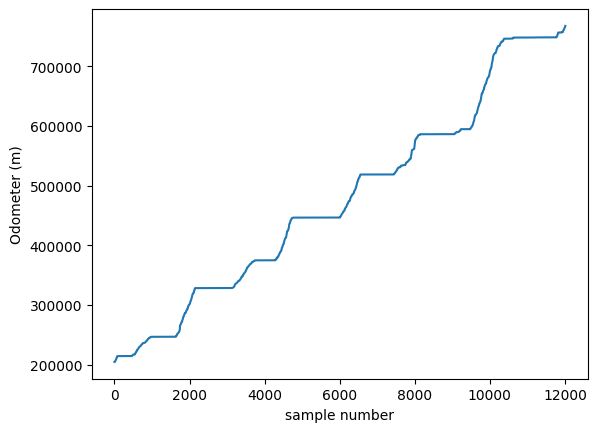

In [8]:
odometer=pd.DataFrame()
odometer_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    print(int(df.iloc[i,3]))
    #if int(df.iloc[i,3]>80000000):
    print(int(df.iloc[i,3]))
    status.append(df.iloc[i,12])
    odometer_data.append(int(df.iloc[i,3]))
    date.append(df.iloc[i,4])
    x_axis.append(i)
try:
    print(max(odometer_data),min(odometer_data))
except:
    print(df.iloc[i,3])

odometer['sample_number']=x_axis
odometer['odometer']=odometer_data
odometer['date']=date
odometer['status']=status

plt.ylabel("Odometer (m)")
plt.xlabel('sample number')
#plt.xticks(range(0,5572,100),rotation=90)
plt.plot(x_axis,odometer_data)

#odometer.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\odometer.csv')

Speed

97 0


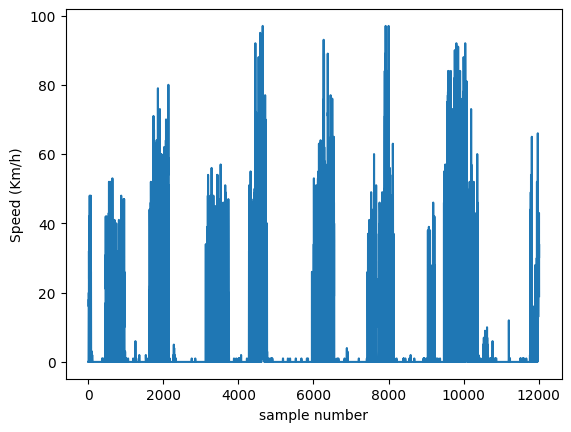

In [9]:
speed=pd.DataFrame()
speed_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):                        
        status.append(df.iloc[i,12])
        speed_data.append(int(df.iloc[i,6]))
        date.append(df.iloc[i,4])
        x_axis.append(i)            

print(max(speed_data),min(speed_data))
speed['sample_number']=x_axis
speed['speed']=speed_data
speed['status']=status

plt.ylabel("Speed (Km/h)")
plt.xlabel('sample number')
plt.plot(x_axis,speed_data)

#speed.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\speed.csv')

RPM

65535


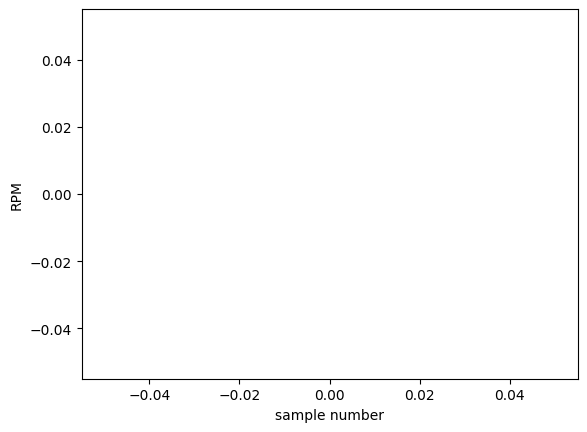

In [10]:
rpm=pd.DataFrame()
rpm_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
        if df.iloc[i,8]<65535:
                status.append(df.iloc[i,12])
                rpm_data.append(int(df.iloc[i,8]))
                date.append(df.iloc[i,4])
                x_axis.append(i)            
try:
    print(max(rpm_data),min(rpm_data))
except:
    print(df.iloc[i,8])

#print(max(rpm_data),min(rpm_data))
rpm['sample_number']=x_axis
rpm['rpm']=rpm_data
rpm['status']=status

plt.ylabel("RPM")
plt.xlabel('sample number')
plt.plot(x_axis,rpm_data)
#rpm.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rpm.csv')

Fuel

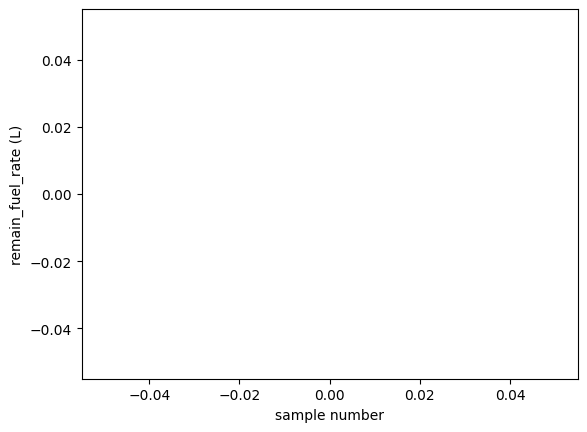

In [11]:
rfl=pd.DataFrame()
fuel_data=[]
x_axis=[]
date=[]
status=[]
status_aux=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,9]!='FF':               
        aux_data=df.iloc[i,12]
        if (len(aux_data)<170):
            status.append(df.iloc[i,12])
            x_axis.append(i) 
            fuel_data.append((int(df.iloc[i,9],16) & 127))
            date.append(df.iloc[i,4])

plt.plot(x_axis,fuel_data)
plt.ylabel("remain_fuel_rate (L)")
plt.xlabel('sample number')

rfl['fuel_data']=fuel_data
rfl['date']=date
rfl['raw_data']=status
#rfl.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rfl_1i1v.csv',sep=',')

Cooling fluid Temperature 

255


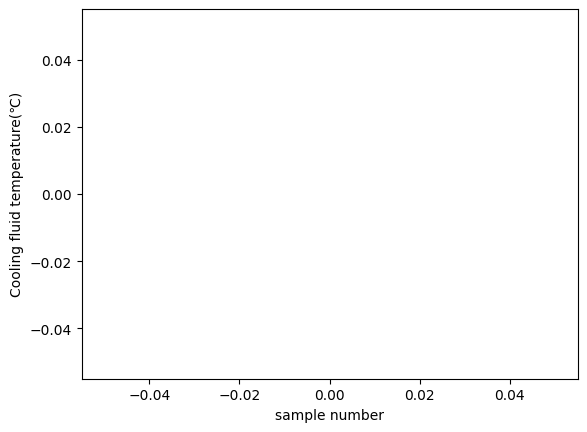

In [12]:
temp=pd.DataFrame()
temp_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,11]!=255:               
        aux_data=df.iloc[i,11]
        status.append(df.iloc[i,12])
        temp_data.append(df.iloc[i,11]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

try:
    print(max(temp_data),min(temp_data))
except:
    print(df.iloc[i,11])
#print(max(temp_data),min(temp_data))
temp['sample_number']=x_axis
temp['date']=date
temp['temp']=temp_data
temp['status']=status

plt.ylabel("Cooling fluid temperature(℃)")
plt.xlabel('sample number')
plt.plot(x_axis,temp_data)

#temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\temp.csv')

Engine load

255


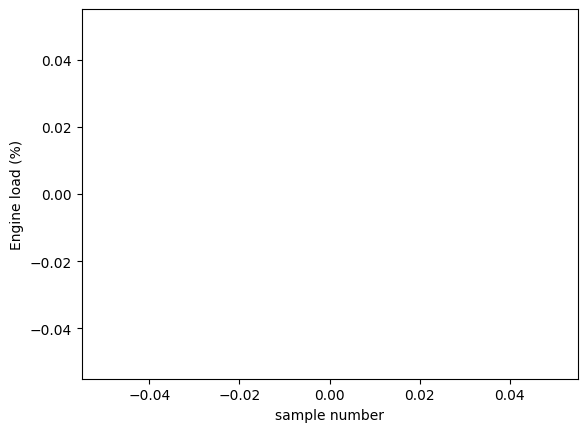

In [13]:
engine_load=pd.DataFrame()
engine_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,13]!=255:               
        aux_data=df.iloc[i,13]
        status.append(df.iloc[i,12])
        engine_data.append(df.iloc[i,13]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

try:
    print(max(engine_data),min(engine_data))
except:
    print(df.iloc[i,13])
#print(max(temp_data),min(temp_data))
engine_load['sample_number']=x_axis
engine_load['date']=date
engine_load['engine load %']=engine_data
engine_load['status']=status

plt.ylabel("Engine load (%)")
plt.xlabel('sample number')
plt.plot(x_axis,engine_data)

#temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\engine.csv')